# 03 Groundwater, Streamflow, and Storage Release

Generates the groundwater-streamflow mass-balance, weekly drainable porosity, wet-season recession, and peak-groundwater sensitivity analyses.


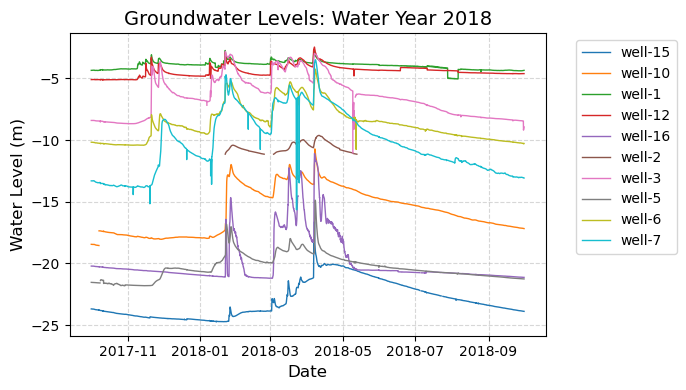

In [1]:
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gp
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
from pysheds.grid import Grid
import os
from matplotlib.ticker import FuncFormatter
from scipy.stats import linregress
import re

profile_wells = gp.read_file('./Data/rivendell_wells.gpkg')


# --- SETTINGS ---
target_wy = 2018  # Change this to any year (e.g., 2024, 2026)
file_path = "./Data/groundwater_hourly_resampled.csv"
# ----------------

# 1. Load the data
df_new = pd.read_csv(file_path, index_col=0, parse_dates=True)

# 2. Define Water Year boundaries
# WY 2025 starts Oct 1, 2024 and ends Sept 30, 2025
start_date = f"{target_wy - 1}-10-01"
end_date = f"{target_wy}-09-30"

# 3. Slice the data for the requested Water Year
df_plot = df_new.loc[start_date:end_date]

# 4. Plotting
if df_plot.empty:
    print(f"No data found for Water Year {target_wy} (Range: {start_date} to {end_date})")
else:
    plt.figure(figsize=(7, 4))
    for column in df_plot.columns:
        plt.plot(df_plot.index, df_plot[column], label=column, linewidth=1)

    plt.title(f'Groundwater Levels: Water Year {target_wy}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Water Level (m)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

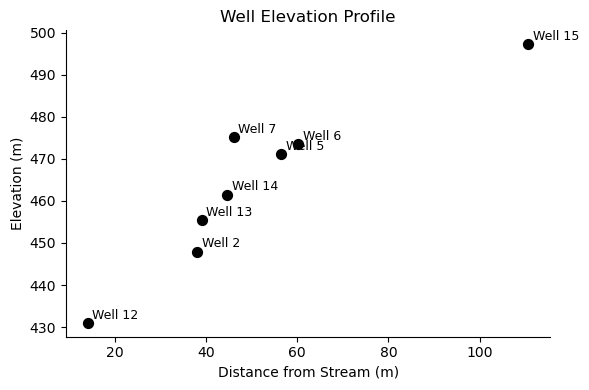

In [2]:
# 1. Sample the Elevation Raster
# Generate coordinate list from the existing GDF geometries
coords = [(x, y) for x, y in zip(profile_wells.geometry.x, profile_wells.geometry.y)]

# Open the elevation raster and sample
with rasterio.open('./Data/elder.tif') as src:
    # src.sample returns a generator; we take the first band value [0] for each point
    profile_wells['elevation'] = [sample[0] for sample in src.sample(coords)]

# 2. Plot Elevation vs. Distance from Stream
f, ax = plt.subplots(figsize=(6, 4))

# Scatter plot
# using 'wellnum' for labels if you want to identify specific wells
ax.scatter(profile_wells['distance'], profile_wells['elevation'], c='black', s=50, zorder=10)

# Optional: Add labels for each well
for idx, row in profile_wells.iterrows():
    # Offset text slightly for readability
    ax.text(row['distance'] + 1, row['elevation'] + 1,
            f"Well {int(row['wellnum'])}", fontsize=9)

# Formatting
ax.set_xlabel('Distance from Stream (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Well Elevation Profile')
sns.despine()
f.tight_layout()

plt.show()

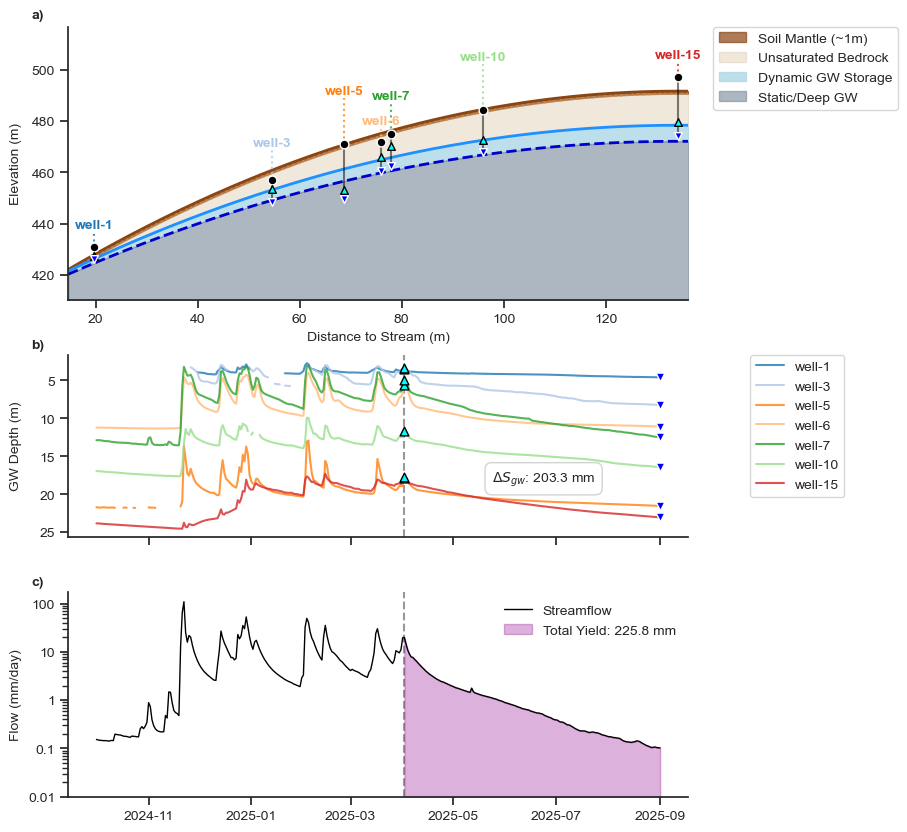

In [3]:
base_path = "./Data"
plots_dir = "./Plots"

if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

dem_file = os.path.join(base_path, "elder.tif")
wells_file = os.path.join(base_path, "wells.gpkg")
gw_file = os.path.join(base_path, "groundwater_hourly_resampled.csv")
flow_file = os.path.join(base_path, "elder_creek_clean.csv")
target_crs = "epsg:26910"

max_gw_date = "2025-04-02"
min_gw_date = "2025-09-01"

ts_start = "2024-10-01"
ts_end   = "2025-09-01"

exclude_wells = ["well-16"]
stream_accumulation_threshold = 1000
drainable_porosity = 0.05

df_gw = pd.read_csv(gw_file, index_col=0, parse_dates=True)
df_gw_daily = df_gw.resample("D").mean()

df_flow = pd.read_csv(flow_file, index_col=0, parse_dates=True)
if df_flow.index.tz is not None:
    df_flow.index = df_flow.index.tz_localize(None)

valid_gw = pd.DataFrame({
    'highest_depth': df_gw_daily.loc[max_gw_date],
    'lowest_depth': df_gw_daily.loc[min_gw_date]
}).dropna()

gdf_wells = gp.read_file(wells_file)

if gdf_wells.crs is not None and gdf_wells.crs.to_string() != target_crs.upper():
    gdf_wells = gdf_wells.to_crs(target_crs)
elif gdf_wells.crs is None:
    gdf_wells.set_crs(target_crs, inplace=True)

if 'Name' in gdf_wells.columns:
    gdf_wells['well_id'] = gdf_wells['Name'].str.lower().str.replace(' ', '-')
elif 'name' in gdf_wells.columns:
    gdf_wells['well_id'] = gdf_wells['name'].str.lower().str.replace(' ', '-')
elif 'wellnum' in gdf_wells.columns:
    gdf_wells['well_id'] = 'well-' + gdf_wells['wellnum'].astype(float).astype(int).astype(str)

gdf_wells = gdf_wells[~gdf_wells['well_id'].isin(exclude_wells)].copy()
gdf_wells = gdf_wells.merge(valid_gw, left_on='well_id', right_index=True, how='inner')

grid = Grid.from_raster(dem_file)
dem = grid.read_raster(dem_file)

pit_filled_dem = grid.fill_pits(dem)
flooded_dem = grid.fill_depressions(pit_filled_dem)
inflated_dem = grid.resolve_flats(flooded_dem)

fdir = grid.flowdir(inflated_dem)
acc = grid.accumulation(fdir)

stream_mask = acc > stream_accumulation_threshold
stream_coords = []
for y, x in zip(*np.where(stream_mask)):
    lon, lat = grid.affine * (x, y)
    stream_coords.append((lon, lat))

stream_tree = cKDTree(stream_coords)
well_coords = [(geom.x, geom.y) for geom in gdf_wells.geometry]

distances, _ = stream_tree.query(well_coords)
gdf_wells['dist_to_stream_m'] = distances

with rasterio.open(dem_file) as src:
    gdf_wells['surface_elev'] = [val[0] for val in src.sample(well_coords)]

gdf_wells['max_gw_elev'] = gdf_wells['surface_elev'] + gdf_wells['highest_depth']
gdf_wells['min_gw_elev'] = gdf_wells['surface_elev'] + gdf_wells['lowest_depth']

gdf_wells = gdf_wells.sort_values('dist_to_stream_m')

x_wells = gdf_wells['dist_to_stream_m'].values
y_surf = gdf_wells['surface_elev'].values
y_max_gw = gdf_wells['max_gw_elev'].values
y_min_gw = gdf_wells['min_gw_elev'].values

if 'well-15' in gdf_wells['well_id'].values:
    x_15 = gdf_wells.loc[gdf_wells['well_id'] == 'well-15', 'dist_to_stream_m'].values[0]
else:
    x_15 = x_wells.max()

def fit_constrained_quadratic(x, y, x_peak):
    u = x**2 - 2 * x_peak * x
    a, c = np.polyfit(u, y, 1)
    b = -2 * a * x_peak
    return np.array([a, b, c])

p_surf = fit_constrained_quadratic(x_wells, y_surf, x_15)
p_max_gw = fit_constrained_quadratic(x_wells, y_max_gw, x_15)
p_min_gw = fit_constrained_quadratic(x_wells, y_min_gw, x_15)

min_plot_dist = max(0, x_wells.min() - 5)
max_plot_dist = x_15 + 2
x_smooth = np.linspace(min_plot_dist, max_plot_dist, 500)

surf_smooth = np.polyval(p_surf, x_smooth)
soil_smooth = surf_smooth - 1.0
max_gw_smooth = np.polyval(p_max_gw, x_smooth)
min_gw_smooth = np.polyval(p_min_gw, x_smooth)

valid_x_range = (x_smooth >= 0) & (x_smooth <= x_15)
x_int = x_smooth[valid_x_range]
max_int = max_gw_smooth[valid_x_range]
min_int = min_gw_smooth[valid_x_range]

cross_sectional_area_m2 = np.trapz(max_int - min_int, x_int)
hillslope_length_m = x_15
avg_drawdown_thickness_m = cross_sectional_area_m2 / hillslope_length_m
storage_loss_mm = avg_drawdown_thickness_m * drainable_porosity * 1000

df_flow_drawdown = df_flow.loc[max_gw_date:min_gw_date]
total_discharge_mm = df_flow_drawdown["flow_mm_day"].sum()

sns.set_theme(style="ticks")
font_size = 10

cmap = plt.get_cmap("tab20")
well_colors = {row['well_id']: cmap(i % 20) for i, (_, row) in enumerate(gdf_wells.iterrows())}

fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[1.8, 1.2, 1.35], hspace=0.25)

ax1 = fig.add_subplot(gs[0])

ax1.fill_between(x_smooth, surf_smooth, soil_smooth, color="saddlebrown", alpha=0.7, label="Soil Mantle (~1m)")
ax1.fill_between(x_smooth, soil_smooth, max_gw_smooth, color="tan", alpha=0.3, label="Unsaturated Bedrock")
ax1.fill_between(x_smooth, max_gw_smooth, min_gw_smooth, color="lightblue", alpha=0.8, label="Dynamic GW Storage")
ax1.fill_between(x_smooth, min_gw_smooth, min(min_gw_smooth) - 20, color="lightslategray", alpha=0.6, label="Static/Deep GW")

ax1.plot(x_smooth, surf_smooth, color="saddlebrown", linewidth=2)
ax1.plot(x_smooth, soil_smooth, color="peru", linewidth=1.5, linestyle=":")
ax1.plot(x_smooth, max_gw_smooth, color="dodgerblue", linewidth=2, linestyle="-")
ax1.plot(x_smooth, min_gw_smooth, color="mediumblue", linewidth=2, linestyle="--")

valid_idx = x_wells <= max_plot_dist
ax1.scatter(x_wells[valid_idx], y_surf[valid_idx], color="black", edgecolor="white", s=40, zorder=5)
ax1.scatter(x_wells[valid_idx], y_max_gw[valid_idx], color="cyan", edgecolor="black", s=30, zorder=5, marker="^")
ax1.scatter(x_wells[valid_idx], y_min_gw[valid_idx], color="blue", edgecolor="white", s=30, zorder=5, marker="v")

for i, (_, row) in enumerate(gdf_wells.iterrows()):
    if row['dist_to_stream_m'] <= max_plot_dist:
        wid = row['well_id']
        w_color = well_colors[wid]

        ax1.vlines(row['dist_to_stream_m'], row['min_gw_elev'], row['surface_elev'], colors='black', linestyles='solid', alpha=0.5, zorder=4)
        y_offset = 6.0 + (i % 3) * 6.0
        label_y = row['surface_elev'] + y_offset

        ax1.vlines(row['dist_to_stream_m'], row['surface_elev'], label_y, colors=w_color, linestyles='dotted', alpha=0.8, zorder=3)
        ax1.text(row['dist_to_stream_m'], label_y, wid, ha='center', va='bottom', fontsize=font_size, fontweight='bold', color=w_color, zorder=6)

ax1.set_xlabel("Distance to Stream (m)", fontsize=font_size)
ax1.set_ylabel("Elevation (m)", fontsize=font_size)
ax1.set_xlim(left=min_plot_dist, right=max_plot_dist)
ax1.set_ylim(bottom=min(min_gw_smooth) - 10, top=max(surf_smooth) + 25)
ax1.tick_params(labelsize=font_size)
ax1.text(-0.06, 1.02, 'a)', transform=ax1.transAxes, fontsize=font_size, fontweight='bold', va='bottom')

sns.despine(ax=ax1)
ax1.legend(loc="upper left", bbox_to_anchor=(1.04, 1), borderaxespad=0., fontsize=font_size)
ax1.grid(False)

df_ts = df_gw_daily.loc[ts_start:ts_end]
df_flow_ts = df_flow.loc[ts_start:ts_end]
dt_max = pd.to_datetime(max_gw_date)
dt_min = pd.to_datetime(min_gw_date)

ax2 = fig.add_subplot(gs[1])

for i, (_, row) in enumerate(gdf_wells.iterrows()):
    if row['dist_to_stream_m'] <= max_plot_dist:
        wid = row['well_id']
        w_color = well_colors[wid]
        ts_depth = -df_ts[wid]

        ax2.plot(ts_depth.index, ts_depth, linewidth=1.5, color=w_color, alpha=0.8, label=wid)
        ax2.scatter(dt_max, -df_ts.loc[max_gw_date, wid], color="cyan", edgecolor="black", s=40, marker="^", zorder=5)
        ax2.scatter(dt_min, -df_ts.loc[min_gw_date, wid], color="blue", edgecolor="white", s=40, marker="v", zorder=5)

ax2.axvline(dt_max, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

ax2.invert_yaxis()
ax2.set_ylabel("GW Depth (m)", fontsize=font_size)
ax2.tick_params(labelsize=font_size)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.text(-0.06, 1.02, 'b)', transform=ax2.transAxes, fontsize=font_size, fontweight='bold', va='bottom')

gw_stats_text = r"$\Delta S_{gw}$: " + f"{storage_loss_mm:.1f} mm"
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="lightgray", alpha=1.0)
ax2.text(0.85, 0.37, gw_stats_text, transform=ax2.transAxes, fontsize=font_size,
         horizontalalignment='right', verticalalignment='top', bbox=bbox_props, zorder=10)

sns.despine(ax=ax2)
ax2.legend(loc="upper left", bbox_to_anchor=(1.1, 1), borderaxespad=0., fontsize=font_size)
ax2.grid(False)

ax3 = fig.add_subplot(gs[2], sharex=ax2)

ax3.plot(df_flow_ts.index, df_flow_ts["flow_mm_day"], color="black", linewidth=1.0, label="Streamflow")
ax3.axvline(dt_max, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

drawdown_period = (df_flow_ts.index >= dt_max) & (df_flow_ts.index <= dt_min)
ax3.fill_between(
    df_flow_ts.index[drawdown_period],
    0.01,
    df_flow_ts.loc[drawdown_period, "flow_mm_day"],
    color="darkmagenta",
    alpha=0.3,
    label=f"Total Yield: {total_discharge_mm:.1f} mm"
)

ax3.set_yscale("log")
ax3.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

ax3.set_ylim(bottom=0.01)
ax3.set_ylabel("Flow (mm/day)", fontsize=font_size)
ax3.tick_params(labelsize=font_size)
ax3.text(-0.06, 1.02, 'c)', transform=ax3.transAxes, fontsize=font_size, fontweight='bold', va='bottom')

ax3.legend(loc="upper right", frameon=False, fontsize=font_size)

sns.despine(ax=ax3)
ax3.grid(False)

fig.align_ylabels([ax1, ax2, ax3])
plt.savefig(os.path.join(plots_dir, "combined_groundwater_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

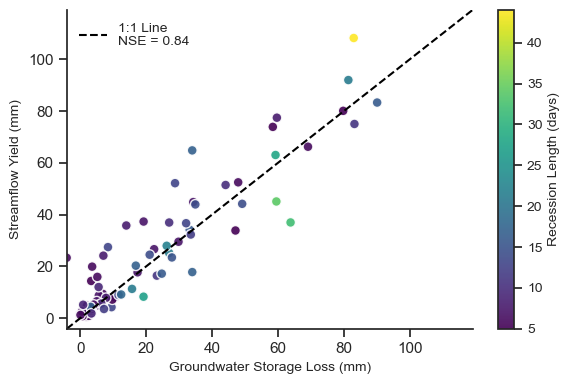

In [4]:
# --- 1. Parameters & Setup ---
base_path = "./Data"
plots_dir = "./Plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

ppt_file = os.path.join(base_path, "prism_ppt.csv")
gw_file = os.path.join(base_path, "groundwater_hourly_resampled.csv")
flow_file = os.path.join(base_path, "elder_creek_clean.csv")

drainable_porosity = 0.05
target_wells = ["well-1", "well-3", "well-5", "well-6", "well-7", "well-10", "well-15"]

# --- Configurable Rainless Period Parameters ---
min_spell_days = 5
max_spell_days = 45

# --- Precip Processing ---
df_ppt = pd.read_csv(ppt_file, index_col=0, parse_dates=True)
df_ppt.index = pd.to_datetime(df_ppt.index)
df_ppt = df_ppt.sort_index()

ppt_col = df_ppt.columns[0]
df_ppt['ppt_mm'] = df_ppt[ppt_col] * 25.4
df_ppt['is_rain'] = df_ppt['ppt_mm'] > 1.0

# --- Find Rainless Spells ---
df_ppt['spell_id'] = df_ppt['is_rain'].cumsum()
rainless = df_ppt[~df_ppt['is_rain']].copy()
spells = rainless.groupby('spell_id').agg(
    start_date=pd.NamedAgg(column='ppt_mm', aggfunc=lambda x: x.index.min()),
    end_date=pd.NamedAgg(column='ppt_mm', aggfunc=lambda x: x.index.max()),
    length=pd.NamedAgg(column='ppt_mm', aggfunc='count')
)

spells = spells[(spells['length'] >= min_spell_days) & (spells['length'] <= max_spell_days)].copy()

valid_months = [11, 12, 1, 2, 3, 4, 5]
spells = spells[spells['start_date'].dt.month.isin(valid_months)].copy()

# --- Load Groundwater and Streamflow ---
df_gw = pd.read_csv(gw_file, index_col=0, parse_dates=True)
df_gw_daily = df_gw.resample("D").mean()

df_flow = pd.read_csv(flow_file, index_col=0, parse_dates=True)
if df_flow.index.tz is not None:
    df_flow.index = df_flow.index.tz_localize(None)

# --- Mass Balance Integration ---
results = []
for _, row in spells.iterrows():
    start = row['start_date']
    end = row['end_date']

    if start not in df_gw_daily.index or end not in df_gw_daily.index:
        continue
    if start not in df_flow.index or end not in df_flow.index:
        continue

    gw_start = df_gw_daily.loc[start, target_wells]
    gw_end = df_gw_daily.loc[end, target_wells]

    if gw_start.isna().any() or gw_end.isna().any():
        continue

    drawdown_m = gw_start - gw_end
    avg_drawdown_m = drawdown_m.mean()
    storage_loss_mm = avg_drawdown_m * drainable_porosity * 1000

    flow_slice = df_flow.loc[start:end, "flow_mm_day"]
    total_discharge_mm = flow_slice.sum()

    initial_discharge = flow_slice.iloc[0] if isinstance(flow_slice, pd.Series) else flow_slice

    results.append({
        'start': start,
        'end': end,
        'length_days': row['length'],
        'gw_loss_mm': storage_loss_mm,
        'stream_yield_mm': total_discharge_mm,
        'initial_flow': initial_discharge
    })

df_results = pd.DataFrame(results)

# --- Statistical Calculations ---
nse = np.nan

if len(df_results) > 1:
    obs = df_results['stream_yield_mm'].values
    sim = df_results['gw_loss_mm'].values

    # Nash-Sutcliffe Efficiency
    nse = 1 - (np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2))

# --- Plotting ---
font_size = 10
plt.rcParams.update({
    'font.size': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size
})
sns.set_theme(style="ticks")

fig, ax = plt.subplots(figsize=(6, 4))

if not df_results.empty:
    scatter = ax.scatter(
        df_results['gw_loss_mm'],
        df_results['stream_yield_mm'],
        c=df_results['length_days'],
        cmap='viridis',
        edgecolor='white',
        s=50,
        alpha=0.9
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Recession Length (days)', fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size)

    max_val = max(df_results['gw_loss_mm'].max(), df_results['stream_yield_mm'].max()) * 1.1
    min_val = min(df_results['gw_loss_mm'].min(), df_results['stream_yield_mm'].min())
    min_val = min(0, min_val)

    legend_label = f'1:1 Line\nNSE = {nse:.2f}'

    ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5, label=legend_label)

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

ax.set_xlabel('Groundwater Storage Loss (mm)', fontsize=font_size)
ax.set_ylabel('Streamflow Yield (mm)', fontsize=font_size)
ax.grid(False)
sns.despine(ax=ax)

ax.legend(loc='upper left', frameon=False, fontsize=font_size)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "gw_vs_streamflow_recession_length.png"), dpi=300, bbox_inches="tight")
plt.show()

Loading data...
Projecting wells and snapping to DEM...


Calculating weekly inferred porosity...

Success! Saved raw weekly data to -> ./Data/weekly_inferred_porosity.csv
Generating analysis plot...
Saved plot -> ./Plots/weekly_inferred_porosity_analysis.png


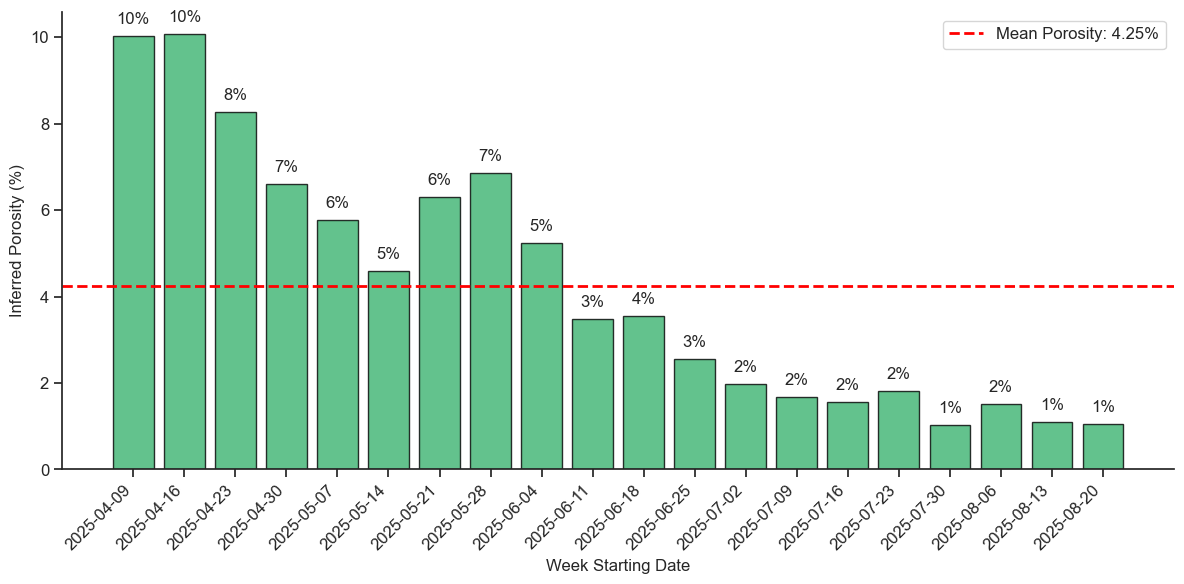

In [5]:
# --- 1. Parameters & Setup ---
data_dir = "./Data"
plots_dir = "./Plots"

if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

dem_file = os.path.join(data_dir, "elder.tif")
wells_file = os.path.join(data_dir, "wells.gpkg")
gw_file = os.path.join(data_dir, "groundwater_hourly_resampled.csv")
flow_file = os.path.join(data_dir, "elder_creek_clean.csv")
target_crs = "epsg:26910"

max_gw_date = "2025-04-09"
min_gw_date = "2025-09-01"
exclude_wells = ["well-16"]
stream_accumulation_threshold = 1000

# --- 2. Load and Prepare Data ---
print("Loading data...")
df_gw = pd.read_csv(gw_file, index_col=0, parse_dates=True)
df_gw_daily = df_gw.resample("D").mean().interpolate(limit=7)

df_flow = pd.read_csv(flow_file, index_col=0, parse_dates=True)
if df_flow.index.tz is not None:
    df_flow.index = df_flow.index.tz_localize(None)

valid_gw = pd.DataFrame({
    'highest_depth': df_gw_daily.loc[max_gw_date],
    'lowest_depth': df_gw_daily.loc[min_gw_date]
}).dropna()

# --- 3. Spatial Processing (Wells & DEM) ---
print("Projecting wells and snapping to DEM...")
gdf_wells = gp.read_file(wells_file)
if gdf_wells.crs is None or gdf_wells.crs.to_string() != target_crs.upper():
    gdf_wells = gdf_wells.to_crs(target_crs)

if 'Name' in gdf_wells.columns:
    gdf_wells['well_id'] = gdf_wells['Name'].str.lower().str.replace(' ', '-')
elif 'name' in gdf_wells.columns:
    gdf_wells['well_id'] = gdf_wells['name'].str.lower().str.replace(' ', '-')

gdf_wells = gdf_wells[~gdf_wells['well_id'].isin(exclude_wells)].copy()
gdf_wells = gdf_wells.merge(valid_gw, left_on='well_id', right_index=True, how='inner')

grid = Grid.from_raster(dem_file)
dem = grid.read_raster(dem_file)
fdir = grid.flowdir(grid.resolve_flats(grid.fill_depressions(grid.fill_pits(dem))))
stream_coords = [grid.affine * (x, y) for y, x in zip(*np.where(grid.accumulation(fdir) > stream_accumulation_threshold))]

stream_tree = cKDTree(stream_coords)
well_coords = [(geom.x, geom.y) for geom in gdf_wells.geometry]
gdf_wells['dist_to_stream_m'], _ = stream_tree.query(well_coords)

with rasterio.open(dem_file) as src:
    gdf_wells['surface_elev'] = [val[0] for val in src.sample(well_coords)]

gdf_wells = gdf_wells.sort_values('dist_to_stream_m')
x_wells = gdf_wells['dist_to_stream_m'].values
y_surf = gdf_wells['surface_elev'].values
x_15 = gdf_wells.loc[gdf_wells['well_id'] == 'well-15', 'dist_to_stream_m'].values[0] if 'well-15' in gdf_wells['well_id'].values else x_wells.max()

x_int = np.linspace(0, x_15, 200)

def fit_constrained_quadratic(x, y, x_peak):
    a, c = np.polyfit(x**2 - 2 * x_peak * x, y, 1)
    return np.array([a, -2 * a * x_peak, c])

# --- 4. WEEKLY MASS BALANCE ANALYSIS ---
print("Calculating weekly inferred porosity...")
dates = pd.date_range(start=max_gw_date, end=min_gw_date, freq='7D')

results = []
for i in range(len(dates) - 1):
    d1 = dates[i]
    d2 = dates[i+1]

    gw1 = df_gw_daily.loc[d1]
    gw2 = df_gw_daily.loc[d2]

    y1_gw = y_surf + [gw1[wid] for wid in gdf_wells['well_id']]
    y2_gw = y_surf + [gw2[wid] for wid in gdf_wells['well_id']]

    p1 = fit_constrained_quadratic(x_wells, y1_gw, x_15)
    p2 = fit_constrained_quadratic(x_wells, y2_gw, x_15)

    smooth_1 = np.polyval(p1, x_int)
    smooth_2 = np.polyval(p2, x_int)

    area_drop = np.trapz(smooth_1 - smooth_2, x_int)
    avg_drop_m = area_drop / x_15
    gw_drop_mm = avg_drop_m * 1000

    end_flow_date = d2 - pd.Timedelta(days=1)
    q_sum_mm = df_flow.loc[d1:end_flow_date, "flow_mm_day"].sum()

    if gw_drop_mm > 0:
        porosity_frac = q_sum_mm / gw_drop_mm
        porosity_pct = porosity_frac * 100
    else:
        porosity_frac = np.nan
        porosity_pct = np.nan

    results.append({
        'Week_Start': d1.strftime('%Y-%m-%d'),
        'Week_End': end_flow_date.strftime('%Y-%m-%d'),
        'Streamflow_Yield_mm': q_sum_mm,
        'Hillslope_Drawdown_mm': gw_drop_mm,
        'Inferred_Porosity_Pct': porosity_pct
    })

df_res = pd.DataFrame(results)
csv_out_path = os.path.join(data_dir, "weekly_inferred_porosity.csv")
df_res.to_csv(csv_out_path, index=False)
print(f"\nSuccess! Saved raw weekly data to -> {csv_out_path}")

# --- 5. PLOTTING THE RESULTS ---
print("Generating analysis plot...")

sns.set_theme(style="ticks")
font_size = 12

df_plot = df_res.dropna(subset=['Inferred_Porosity_Pct']).copy()

fig, ax_por = plt.subplots(figsize=(12, 6))

x_labels = df_plot['Week_Start'].tolist()
x_positions = np.arange(len(df_plot))

bars = ax_por.bar(x_positions, df_plot['Inferred_Porosity_Pct'], color='mediumseagreen', edgecolor='black', alpha=0.8)

mean_porosity = df_plot['Inferred_Porosity_Pct'].mean()
ax_por.axhline(mean_porosity, color='red', linestyle='--', linewidth=2, label=f'Mean Porosity: {mean_porosity:.2f}%')

ax_por.set_ylabel("Inferred Porosity (%)", fontsize=font_size)
ax_por.set_xlabel("Week Starting Date", fontsize=font_size)
ax_por.grid(False)

for bar in bars:
    yval = bar.get_height()
    ax_por.text(bar.get_x() + bar.get_width()/2, yval + (ax_por.get_ylim()[1]*0.02), f'{yval:.0f}%', ha='center', va='bottom', fontsize=font_size)

ax_por.set_xticks(x_positions)
ax_por.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=font_size)
ax_por.tick_params(axis='both', labelsize=font_size)

sns.despine(ax=ax_por)
ax_por.legend(loc='upper right', fontsize=font_size)

plt.tight_layout()
plot_out_path = os.path.join(plots_dir, "weekly_inferred_porosity_analysis.png")
plt.savefig(plot_out_path, dpi=150, bbox_inches="tight")
print(f"Saved plot -> {plot_out_path}")
plt.show()

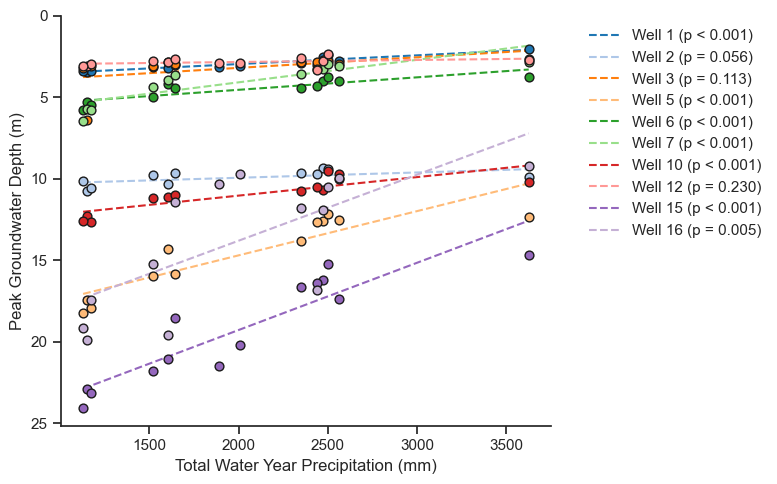

In [6]:
# --- Parameters & Paths ---
base_path = "./Data"
plots_dir = "./Plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

ppt_file = os.path.join(base_path, "prism_ppt.csv")
gw_file = os.path.join(base_path, "groundwater_hourly_resampled.csv")

font_size = 10
plt.rcParams.update({
    'font.size': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size
})
sns.set_theme(style="ticks")

def extract_well_num(name):
    nums = re.findall(r'\d+', str(name))
    return int(nums[0]) if nums else str(name)

# ==========================================
# 1. PROCESS PRECIPITATION
# ==========================================
rainfall = pd.read_csv(ppt_file, index_col=0, parse_dates=True)
if rainfall.index.tz is not None:
    rainfall.index = rainfall.index.tz_localize(None)

ppt_col = rainfall.columns[0]
rainfall = rainfall[[ppt_col]].rename(columns={ppt_col: 'ppt'})
rainfall['ppt'] = rainfall['ppt'] * 25.4

rainfall['WY'] = np.where(rainfall.index.month >= 10, rainfall.index.year + 1, rainfall.index.year)

wy_ppt_counts = rainfall.groupby('WY').size()
valid_wys = wy_ppt_counts[wy_ppt_counts >= 365].index
annual_ppt = rainfall[rainfall['WY'].isin(valid_wys)].groupby('WY')['ppt'].sum().to_frame(name='Total_Precip_mm')

# ==========================================
# 2. PROCESS GROUNDWATER
# ==========================================
df_gw = pd.read_csv(gw_file, index_col=0, parse_dates=True)
if df_gw.index.tz is not None:
    df_gw.index = df_gw.index.tz_localize(None)

df_gw['WY'] = np.where(df_gw.index.month >= 10, df_gw.index.year + 1, df_gw.index.year)

gw_cols = [c for c in df_gw.columns if c != 'WY']
for col in gw_cols:
    df_gw[col] = -df_gw[col]

annual_gw_peaks = []
for wy, group in df_gw.groupby('WY'):
    if wy not in annual_ppt.index:
        continue

    if len(group) < (180 * 24):
        continue

    daily_depths = group[gw_cols].resample('D').median()
    daily_depths = daily_depths[daily_depths >= 0.5]  # Filter erroneous surface spikes
    peak_depths = daily_depths.min()

    record = {'WY': wy}
    for col in gw_cols:
        record[col] = peak_depths[col]

    annual_gw_peaks.append(record)

df_peaks = pd.DataFrame(annual_gw_peaks).set_index('WY')
df_plot = annual_ppt.join(df_peaks, how='inner').dropna(how='all', subset=gw_cols)

# ==========================================
# 3. COLOR MAPPING & SORTING
# ==========================================
sorted_wells = sorted(gw_cols, key=extract_well_num)
well_nums = [extract_well_num(w) for w in sorted_wells]
master_palette = sns.color_palette("tab20", len(sorted_wells))
well_color_map = dict(zip(well_nums, master_palette))

# ==========================================
# 4. PLOTTING
# ==========================================
fig, ax = plt.subplots(figsize=(8, 5))

for well in sorted_wells:
    well_num = extract_well_num(well)

    valid_data = df_plot.dropna(subset=[well])
    if valid_data.empty:
        continue

    x = valid_data['Total_Precip_mm'].values
    y = valid_data[well].values

    if len(x) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        x_trend = np.array([x.min(), x.max()])
        y_trend = slope * x_trend + intercept

        # Cleanly format the p-value
        p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
        label_text = f'Well {well_num} ({p_text})'

        # Plot line and opaque scatter points
        ax.plot(x_trend, y_trend, color=well_color_map[well_num], linestyle='--', zorder=2, label=label_text)
        ax.scatter(x, y, color=well_color_map[well_num], s=40, edgecolor='k', zorder=3)
    else:
        ax.scatter(x, y, color=well_color_map[well_num], label=f'Well {well_num}', s=40, edgecolor='k', zorder=3)

ax.set_xlabel('Total Water Year Precipitation (mm)')
ax.set_ylabel('Peak Groundwater Depth (m)')

# Invert Y-axis so ground surface (0) is at the top
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_max, max(0, y_min - 2))

ax.grid(False)
sns.despine()

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()

save_path = os.path.join(plots_dir, "gw_max_vs_precip.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()